import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

df1=pd.read_csv("effect_tb.csv",header=None,names=["dt","user_id","label","dmp_id"])
print("前五行")
df1.head()
df1.shape

In [13]:
df1.describe()

,dt,user_id,label,dmp_id
count,2.645958e+06,2.645958e+06,2.645958e+06,2.645958e+06
mean,1.440575e+00,3.112995e+06,1.456297e-02,1.395761e+00
std,4.964562e-01,1.828262e+06,1.197952e-01,6.920480e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
25%,1.000000e+00,1.526772e+06,0.000000e+00,1.000000e+00
50%,1.000000e+00,3.062184e+06,0.000000e+00,1.000000e+00
75%,2.000000e+00,4.721132e+06,0.000000e+00,2.000000e+00
max,2.000000e+00,6.265402e+06,1.000000e+00,3.000000e+00


In [17]:
df1=df1[(df1["label"].isin([0,1]))&(df1["dmp_id"].isin([1,2,3]))]
df1=df1.drop("dt",axis=1)
df1.describe()

,user_id,label,dmp_id
count,2.645958e+06,2.645958e+06,2.645958e+06
mean,3.112995e+06,1.456297e-02,1.395761e+00
std,1.828262e+06,1.197952e-01,6.920480e-01
min,1.000000e+00,0.000000e+00,1.000000e+00
25%,1.526772e+06,0.000000e+00,1.000000e+00
50%,3.062184e+06,0.000000e+00,1.000000e+00
75%,4.721132e+06,0.000000e+00,2.000000e+00
max,6.265402e+06,1.000000e+00,3.000000e+00


In [18]:
print(f"清洗后的数据形状：{df1.shape}")

清洗后的数据形状：(2645958, 3)


In [23]:
df3=pd.read_csv("seed_cand_tb.csv",header=None,names=["dt","user_id","user_type"])
df3=df3.drop("dt",axis=1)
df3.head()

,user_id,user_type
0,1,cand
1,10,cand
2,1000,seed
3,100000,cand
4,1000000,cand


In [24]:
df3.shape

(6306020, 2)

In [25]:
df3["type"]=df3["user_type"].map({"seed":0,"cand":1})
df3.head()

,user_id,user_type,type
0,1,cand,1
1,10,cand,1
2,1000,seed,0
3,100000,cand,1
4,1000000,cand,1


In [26]:
df3=df3.drop("user_type",axis=1)
df3=df3.drop_duplicates("user_id")
print(f"清洗后的数据形状：{df3.shape}")

清洗后的数据形状：(6265402, 2)


In [27]:
df3.head()

,user_id,type
0,1,1
1,10,1
2,1000,0
3,100000,1
4,1000000,1


In [31]:
df2=pd.read_csv("emb_tb_2.csv",header=None,names=["user_id","emb_str"])
df2.head()

,user_id,emb_str
0,5892737,"0.2638,0.19196,-0.06571,0.31552,-0.41134,0.012..."
1,5892738,"0.29082,0.28176,-0.11427,0.28056,-0.4288,-0.03..."
2,5892745,"0.25179,0.16881,-0.06665,0.2805,-0.43631,0.024..."
3,5892768,"0.27312,0.21038,-0.07908,0.28003,-0.43439,0.00..."
4,5892777,"0.21304,0.19142,-0.06493,0.35574,-0.41979,-0.0..."


In [34]:
emb_split=df2["emb_str"].str.split(",",expand=True)
emb_split

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.2638,0.19196,-0.06571,0.31552,-0.41134,0.01294,-0.39399,0.10207,-0.2452,-0.03287,-0.26336,-0.04235,0.40634,-0.01859,0.35083,0.18381
1,0.29082,0.28176,-0.11427,0.28056,-0.4288,-0.03991,-0.43013,0.08772,-0.29534,-0.05485,-0.22496,-0.06377,0.24891,-0.03478,0.34808,0.19202
2,0.25179,0.16881,-0.06665,0.2805,-0.43631,0.02476,-0.40969,0.0711,-0.25469,-0.05323,-0.2791,-0.06482,0.40207,-0.00314,0.3397,0.18502
3,0.27312,0.21038,-0.07908,0.28003,-0.43439,0.00282,-0.41195,0.08062,-0.26868,-0.04776,-0.26168,-0.0626,0.35814,-0.01359,0.34717,0.18901
4,0.21304,0.19142,-0.06493,0.35574,-0.41979,-0.04193,-0.39714,0.07881,-0.25411,-0.03936,-0.25975,-0.07417,0.37517,-0.03424,0.36326,0.17976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.1997,0.14856,-0.10435,0.21601,-0.48457,0.04344,-0.50176,-0.02338,-0.27719,-0.14748,-0.28324,-0.11321,0.29493,0.03032,0.25899,0.21188
99996,0.23636,0.14594,-0.08961,0.22119,-0.43399,0.10155,-0.46159,0.03254,-0.25356,-0.12985,-0.29448,-0.07046,0.39655,0.06708,0.25893,0.22685
99997,0.21732,0.11209,-0.15215,0.16304,-0.46253,0.12918,-0.50917,0.02226,-0.27355,-0.16787,-0.32594,-0.08009,0.30701,0.04042,0.26109,0.14278
99998,0.22469,0.14996,-0.02431,0.25049,-0.4383,0.03524,-0.41479,0.01333,-0.2428,-0.09353,-0.26427,-0.10318,0.44588,0.05981,0.27155,0.27167


In [35]:
emb_split.columns=[f"emb_{i}"for i in range(emb_split.shape[1])]
emb_split

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15
0,0.2638,0.19196,-0.06571,0.31552,-0.41134,0.01294,-0.39399,0.10207,-0.2452,-0.03287,-0.26336,-0.04235,0.40634,-0.01859,0.35083,0.18381
1,0.29082,0.28176,-0.11427,0.28056,-0.4288,-0.03991,-0.43013,0.08772,-0.29534,-0.05485,-0.22496,-0.06377,0.24891,-0.03478,0.34808,0.19202
2,0.25179,0.16881,-0.06665,0.2805,-0.43631,0.02476,-0.40969,0.0711,-0.25469,-0.05323,-0.2791,-0.06482,0.40207,-0.00314,0.3397,0.18502
3,0.27312,0.21038,-0.07908,0.28003,-0.43439,0.00282,-0.41195,0.08062,-0.26868,-0.04776,-0.26168,-0.0626,0.35814,-0.01359,0.34717,0.18901
4,0.21304,0.19142,-0.06493,0.35574,-0.41979,-0.04193,-0.39714,0.07881,-0.25411,-0.03936,-0.25975,-0.07417,0.37517,-0.03424,0.36326,0.17976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.1997,0.14856,-0.10435,0.21601,-0.48457,0.04344,-0.50176,-0.02338,-0.27719,-0.14748,-0.28324,-0.11321,0.29493,0.03032,0.25899,0.21188
99996,0.23636,0.14594,-0.08961,0.22119,-0.43399,0.10155,-0.46159,0.03254,-0.25356,-0.12985,-0.29448,-0.07046,0.39655,0.06708,0.25893,0.22685
99997,0.21732,0.11209,-0.15215,0.16304,-0.46253,0.12918,-0.50917,0.02226,-0.27355,-0.16787,-0.32594,-0.08009,0.30701,0.04042,0.26109,0.14278
99998,0.22469,0.14996,-0.02431,0.25049,-0.4383,0.03524,-0.41479,0.01333,-0.2428,-0.09353,-0.26427,-0.10318,0.44588,0.05981,0.27155,0.27167


In [55]:
df_emb_clean=pd.concat([df2["user_id"],emb_split],axis=1)
df_emb_clean

,user_id,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15
0,5892737,0.2638,0.19196,-0.06571,0.31552,-0.41134,0.01294,-0.39399,0.10207,-0.2452,-0.03287,-0.26336,-0.04235,0.40634,-0.01859,0.35083,0.18381
1,5892738,0.29082,0.28176,-0.11427,0.28056,-0.4288,-0.03991,-0.43013,0.08772,-0.29534,-0.05485,-0.22496,-0.06377,0.24891,-0.03478,0.34808,0.19202
2,5892745,0.25179,0.16881,-0.06665,0.2805,-0.43631,0.02476,-0.40969,0.0711,-0.25469,-0.05323,-0.2791,-0.06482,0.40207,-0.00314,0.3397,0.18502
3,5892768,0.27312,0.21038,-0.07908,0.28003,-0.43439,0.00282,-0.41195,0.08062,-0.26868,-0.04776,-0.26168,-0.0626,0.35814,-0.01359,0.34717,0.18901
4,5892777,0.21304,0.19142,-0.06493,0.35574,-0.41979,-0.04193,-0.39714,0.07881,-0.25411,-0.03936,-0.25975,-0.07417,0.37517,-0.03424,0.36326,0.17976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,103731,0.1997,0.14856,-0.10435,0.21601,-0.48457,0.04344,-0.50176,-0.02338,-0.27719,-0.14748,-0.28324,-0.11321,0.29493,0.03032,0.25899,0.21188
99996,103736,0.23636,0.14594,-0.08961,0.22119,-0.43399,0.10155,-0.46159,0.03254,-0.25356,-0.12985,-0.29448,-0.07046,0.39655,0.06708,0.25893,0.22685
99997,103741,0.21732,0.11209,-0.15215,0.16304,-0.46253,0.12918,-0.50917,0.02226,-0.27355,-0.16787,-0.32594,-0.08009,0.30701,0.04042,0.26109,0.14278
99998,103760,0.22469,0.14996,-0.02431,0.25049,-0.4383,0.03524,-0.41479,0.01333,-0.2428,-0.09353,-0.26427,-0.10318,0.44588,0.05981,0.27155,0.27167


In [56]:
feature_cols=[col for col in df_emb_clean.columns if col.startswith("emb_")]
df_emb_clean[feature_cols]=df_emb_clean[feature_cols].astype(float)
df_emb_clean=df_emb_clean.drop_duplicates("user_id")
df_emb_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  100000 non-null  int64  
 1   emb_0    100000 non-null  float64
 2   emb_1    100000 non-null  float64
 3   emb_2    100000 non-null  float64
 4   emb_3    100000 non-null  float64
 5   emb_4    100000 non-null  float64
 6   emb_5    100000 non-null  float64
 7   emb_6    100000 non-null  float64
 8   emb_7    100000 non-null  float64
 9   emb_8    100000 non-null  float64
 10  emb_9    100000 non-null  float64
 11  emb_10   100000 non-null  float64
 12  emb_11   100000 non-null  float64
 13  emb_12   100000 non-null  float64
 14  emb_13   100000 non-null  float64
 15  emb_14   100000 non-null  float64
 16  emb_15   100000 non-null  float64
dtypes: float64(16), int64(1)
memory usage: 13.0 MB


In [45]:
df_merge=pd.merge(left=df1,right=df3,on="user_id",how="left")
df_merge.head()

,user_id,label,dmp_id,type
0,1,0,1,1
1,1000004,0,1,1
2,1000004,0,2,1
3,1000006,0,1,1
4,1000006,0,3,1


In [48]:
df_merge["type"]=df_merge["type"].fillna(2)

In [49]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2645958 entries, 0 to 2645957
Data columns (total 4 columns):
 #   Column   Dtype
---  ------   -----
 0   user_id  int64
 1   label    int64
 2   dmp_id   int64
 3   type     int64
dtypes: int64(4)
memory usage: 80.7 MB


In [57]:
df_full=pd.merge(left=df_merge,right=df_emb_clean,on="user_id",how="left")
df_full

,user_id,label,dmp_id,type,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15
0,1,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000004,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1000004,0,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000006,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000006,0,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2645953,999966,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2645954,999971,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2645955,99999,0,2,1,0.26807,0.16073,-0.05297,0.30578,-0.41166,0.05309,-0.42654,0.10525,-0.22202,-0.04889,-0.21716,-0.02289,0.44246,-0.03304,0.31123,0.21818
2645956,999990,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
type_map={0:"种子选手",1:"扩展候选用户",2:"未知用户"}
dmp_map={1:"对照组",2:"策略1",3:"策略2"}
label_map={0:"未点击",1:"点击"}
df_full["人群分类"]=df_full["type"].map(type_map)
df_full["投放策略"]=df_full["dmp_id"].map(dmp_map)
df_full["是否点击"]=df_full["label"].map(label_map)
df_full.head(2)

,user_id,label,dmp_id,type,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,...,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,人群分类,投放策略,是否点击
0,1,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,扩展候选用户,对照组,未点击
1,1000004,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,扩展候选用户,对照组,未点击


In [111]:
import numpy as np
from scipy.stats import norm

def calc_min_sample_size(baseline_p, mde_abs, alpha=0.05, power=0.8):
    """
    两组比例A/B测试 每组最小样本量计算
    :param baseline_p: 对照组基线CTR
    :param mde_abs: 最小可检测绝对提升百分点
    :param alpha: 显著性水平
    :param power: 统计功效1-β
    :return: 每组所需最小样本整数
    """
    # 分位数
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    
    p0 = baseline_p
    p1 = baseline_p + mde_abs
    p_pool = (p0 + p1) / 2
    
    numerator = (z_alpha + z_beta) ** 2 * 2 * p_pool * (1 - p_pool)
    denominator = (p1 - p0) ** 2
    n_per_group = numerator / denominator
    
    return int(np.ceil(n_per_group))

# ---------------------- 1、计算本次实验最小样本阈值 ----------------------
baseline_ctr = 0.0125   # 对照组基线1.25%
min_abs_gain = 0.01     # 预期最小提升1个百分点
min_n = calc_min_sample_size(baseline_ctr, min_abs_gain)

print("===== 样本容量计算结果 =====")
print(f"基线点击率：{baseline_ctr:.2%}")
print(f"设定最小可检测绝对提升：{min_abs_gain:.2%}")
print(f"α=0.05，power=0.8，每组最低所需样本量：{min_n}\n")

# ---------------------- 2、校验各分层实际样本是否达标 ----------------------
# 分层样本数据（取自你的ctr_layer结果）
sample_dict = {
    "对照组-扩展候选用户": 19159290,
    "策略1-扩展候选用户": 412678,
    "策略2-扩展候选用户": 317245,
    "对照组-种子选手": 106,
    "策略1-种子选手": 17,
    "策略2-种子选手": 16
}

print("===== 各分层样本容量达标校验 =====")
for name, sample_num in sample_dict.items():
    flag = "✅达标" if sample_num >= min_n else "❌样本不足，无统计效力"
    print(f"{name}：曝光{sample_num:,}，最低阈值{min_n} → {flag}")

===== 样本容量计算结果 =====
基线点击率：1.25%
设定最小可检测绝对提升：1.00%
α=0.05，power=0.8，每组最低所需样本量：2700

===== 各分层样本容量达标校验 =====
对照组-扩展候选用户：曝光19,159,290，最低阈值2700 → ✅达标
策略1-扩展候选用户：曝光412,678，最低阈值2700 → ✅达标
策略2-扩展候选用户：曝光317,245，最低阈值2700 → ✅达标
对照组-种子选手：曝光106，最低阈值2700 → ❌样本不足，无统计效力
策略1-种子选手：曝光17，最低阈值2700 → ❌样本不足，无统计效力
策略2-种子选手：曝光16，最低阈值2700 → ❌样本不足，无统计效力


In [65]:
def calc_ctr(sub_df):
    total=len(sub_df)
    click=sub_df["label"].sum()
    ctr=click/total if total>0 else 0
    return pd.Series([total,click,round(ctr,4)],index=["曝光人数","点击人数","CTR"])

In [109]:
from scipy.stats import chisquare
def check_srm(df):
    group_cnt=df["dmp_id"].value_counts().sort_index()
    total=group_cnt.sum()
    exp=[total/3]*3
    chi,p=chisquare(group_cnt.values,exp)
    return chi,p
check_srm(df_full)

(np.float64(1823656.759116358), np.float64(0.0))

In [110]:
from scipy.stats import chisquare
def check_srm(df):
    group_cnt = df["dmp_id"].value_counts().sort_index()
    total = group_cnt.sum()
    exp = [total / 3] * 3
    chi2, p = chisquare(group_cnt.values, exp)
    print("==== SRM分流校验(A/B实验前置必做) ====")
    print(f"三组样本量：{dict(group_cnt)}")
    print(f"卡方={chi2:.2f}, P值={p:.4f}")
    if p < 0.01:
        print("⚠️ 警告：样本分配不均衡，实验可信度下降！")
    else:
        print("✅ 样本随机分配均衡，数据可信")
    return p
check_srm(df_full)

==== SRM分流校验(A/B实验前置必做) ====
三组样本量：{1: np.int64(1916035), 2: np.int64(412678), 3: np.int64(317245)}
卡方=1823656.76, P值=0.0000
⚠️ 警告：样本分配不均衡，实验可信度下降！


np.float64(0.0)

In [ ]:
#全策略CTR
ctr_strategy=df_full.groupby("投放策略").apply(calc_ctr)
ctr_strategy

In [75]:
#分层，策略+人群
ctr_layer=df_full.groupby(["投放策略","人群分类"]).apply(calc_ctr)
ctr_layer

曝光人数     点击人数     CTR
投放策略 人群分类                              
对照组  扩展候选用户  1915929.0  23932.0  0.0125
     种子选手        106.0      4.0  0.0377
策略1  扩展候选用户   412661.0   6305.0  0.0153
     种子选手         17.0      2.0  0.1176
策略2  扩展候选用户   317229.0   8290.0  0.0261
     种子选手         16.0      0.0  0.0000

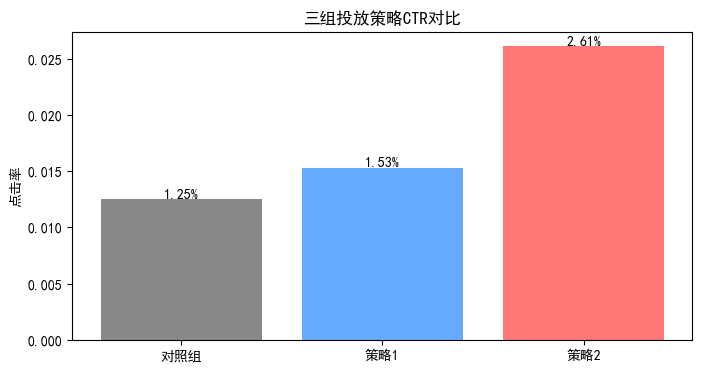

In [77]:
plt.figure(figsize=(8,4))
plt.bar(ctr_strategy.index, ctr_strategy["CTR"], color=["#888888","#66aaff","#ff7777"])
for i, val in enumerate(ctr_strategy["CTR"]):
    plt.text(i, val+0.0001, f"{val:.2%}", ha="center")
plt.title("三组投放策略CTR对比")
plt.ylabel("点击率")
plt.show()

In [80]:
ctrl=df_full[df_full["dmp_id"]==1]
ctrl_n=len(ctrl)
ctrl_click=ctrl["label"].sum()
ctr_ctrl=ctrl_click/ctrl_n
print(f"对照组CTR：{ctr_ctrl}")

对照组CTR：0.012492464908000114


In [91]:
def ab_test(exp_id,exp_name):
    exp=df_full[df_full["dmp_id"]==exp_id]
    exp_n=len(exp)
    exp_click=exp["label"].sum()
    z,p=proportions_ztest([exp_click,ctrl_click],[exp_n,ctrl_n],alternative="larger")
    ctr_exp=exp_click/exp_n
    lift=ctr_exp-ctr_ctrl
    return pd.Series([exp_name,round(ctr_ctrl,4),round(ctr_exp,4),round(lift,4),round(z,2),p,p<0.05],
                     index=["实验组","对照组CTR","实验组CTR","提升幅度","Z值","P值","统计显著（阿法=0.05）"]                  
                    )

In [92]:
test_res=pd.DataFrame([ab_test(2,"策略1"),ab_test(3,"策略2")])
test_res

,实验组,对照组CTR,实验组CTR,提升幅度,Z值,P值,统计显著（阿法=0.05）
0,策略1,0.0125,0.0153,0.0028,14.36,4.433469e-47,True
1,策略2,0.0125,0.0261,0.0136,59.67,0.000000e+00,True


In [95]:
df_cluster=df_full.dropna(subset=feature_cols)
df_cluster.shape

(43973, 23)

In [97]:
X=df_cluster[feature_cols]
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaler=scaler.fit_transform(X)

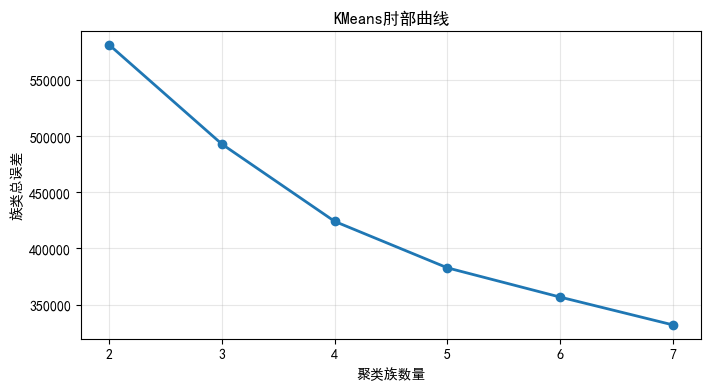

In [99]:
#肘部验证
from sklearn.cluster import KMeans
sse_list=[]
k_range=range(2,8)
for k in k_range:
    km_temp=KMeans(n_clusters=k,random_state=42)
    km_temp.fit(X_scaler)
    sse_list.append(km_temp.inertia_)
plt.figure(figsize=(8,4))
plt.plot(k_range,sse_list,marker="o",linewidth=2)
plt.xlabel("聚类族数量")
plt.ylabel("族类总误差")
plt.title("KMeans肘部曲线")
plt.grid(alpha=0.3)
plt.show()


In [101]:
#k取4
kmeans=KMeans(n_clusters=4,random_state=42)
df_cluster["画像族"]=kmeans.fit_predict(X_scaler)
df_cluster.head(2)

,user_id,label,dmp_id,type,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,...,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,人群分类,投放策略,是否点击,画像族
19,100004,0,1,1,0.25512,0.13079,-0.02937,0.22824,-0.47325,0.03507,...,-0.2459,-0.08868,0.42597,-0.00998,0.30054,0.22385,扩展候选用户,对照组,未点击,2
35,100009,0,1,1,0.25057,0.15648,-0.03668,0.26567,-0.45048,0.01854,...,-0.2642,-0.07989,0.42361,0.00368,0.32308,0.21638,扩展候选用户,对照组,未点击,2


In [102]:
cluster_ctr=df_cluster.groupby("画像族").apply(calc_ctr)
cluster_ctr

,曝光人数,点击人数,CTR
画像族,,,
0,3747.0,163.0,0.0435
1,17691.0,180.0,0.0102
2,12598.0,114.0,0.0090
3,9937.0,150.0,0.0151


In [104]:
best_cluster_data=df_cluster[df_cluster["画像族"]==0]
best_dist=best_cluster_data["投放策略"].value_counts(normalize=True)
print(best_dist)

投放策略
对照组    0.617294
策略2    0.197224
策略1    0.185482
Name: proportion, dtype: float64
